In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore')
data_path = '/content/drive/MyDrive/Colab Notebooks/VNM_macro_cleaned.csv'

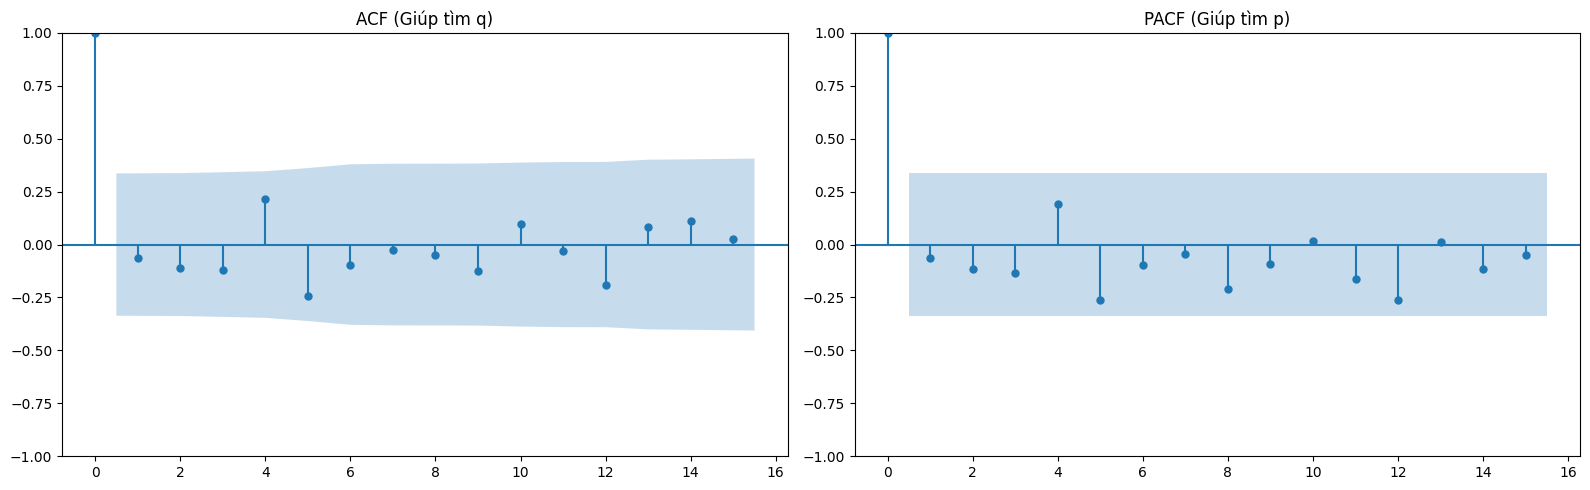

In [60]:
# 1. Chuẩn bị dữ liệu
df = pd.read_csv(data_path)
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)
target = 'Economic_Openness_Pct'

# 2. Lấy sai phân bậc 1 (Vì trước đó ADF cho thấy chuỗi gốc không dừng)
# .dropna() để loại bỏ giá trị NaN ở dòng đầu tiên sau khi trừ
diff_data = df[target].diff().dropna()

# 3. Vẽ biểu đồ ACF và PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Vẽ ACF để tìm q
# lags=15 vì dữ liệu ta chỉ có 35 năm, không nên nhìn quá xa
plot_acf(diff_data, lags=15, ax=axes[0], title='ACF (Giúp tìm q)')

# Vẽ PACF để tìm p
plot_pacf(diff_data, lags=15, ax=axes[1], title='PACF (Giúp tìm p)', method='ywm')

plt.tight_layout()
plt.show()

Đang huấn luyện các mô hình...

--- KẾT QUẢ TRÊN TẬP TEST (2020-2024) ---
ARIMA (Drift) -> RMSE: 10.35 | MAE: 9.40
ARIMAX (Log FDI) -> RMSE: 13.14 | MAE: 9.91


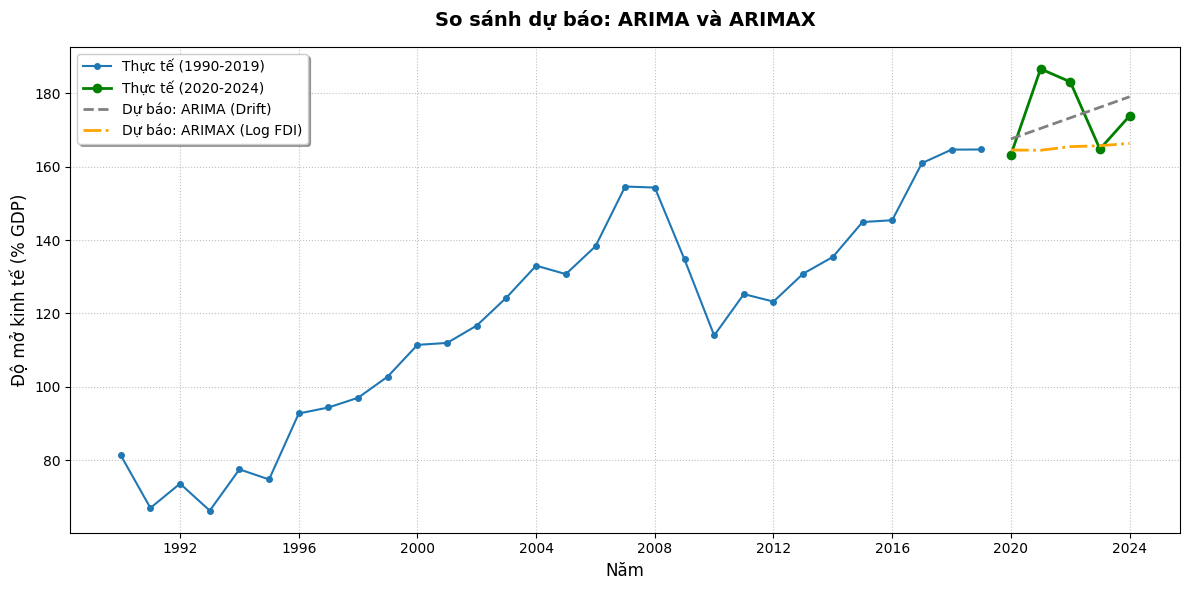


--- TÓM TẮT THỐNG KÊ MÔ HÌNH ARIMAX ---
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Log_FDI_Inflows     7.4221      4.410      1.683      0.092      -1.221      16.065
sigma2             88.1673     25.169      3.503      0.000      38.837     137.498


In [69]:


# ==========================================
# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
df = pd.read_csv(data_path)
df['Year'] = pd.to_datetime(df['Year'], format='%Y')
df.set_index('Year', inplace=True)

target = 'Economic_Openness_Pct'

# Chuyển đổi FDI sang Logarit làm biến ngoại sinh cho ARIMAX
df['Log_FDI_Inflows'] = np.log(df['FDI_Inflows_USD'])

df = df.dropna()

# 2. CHIA TẬP TRAIN / TEST
train_size = len(df) - 5
train = df.iloc[:train_size]
test = df.iloc[train_size:]

exog_train = train[['Log_FDI_Inflows']]
exog_test = test[['Log_FDI_Inflows']]

print("Đang huấn luyện các mô hình...")

# 3. MÔ HÌNH 1: ARIMA CƠ BẢN (Không biến ngoại sinh)
# Dùng trend='t' (linear trend) khi d=1 để tạo ra Drift
model_arima = ARIMA(train[target], order=(0, 1, 0), trend='t')
fitted_arima = model_arima.fit()
pred_arima = fitted_arima.forecast(steps=len(test))

# 4. MÔ HÌNH 2: ARIMAX (Có biến ngoại sinh X)
# Mô hình có biến ngoại sinh (exog) tự động xử lý xu hướng thông qua biến X
model_arimax = ARIMA(train[target], exog=exog_train, order=(0, 1, 0))
fitted_arimax = model_arimax.fit()
pred_arimax = fitted_arimax.forecast(steps=len(test), exog=exog_test)

# 5. ĐÁNH GIÁ SAI SỐ
def print_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.2f} | MAE: {mae:.2f}")

print("\n--- KẾT QUẢ TRÊN TẬP TEST (2020-2024) ---")
print_metrics("ARIMA (Drift)", test[target], pred_arima)
print_metrics("ARIMAX (Log FDI)", test[target], pred_arimax)


# 6. TRỰC QUAN HÓA SO SÁNH
plt.figure(figsize=(12, 6))

# Dữ liệu thực tế
plt.plot(train.index, train[target], label='Thực tế (1990-2019)', marker='o', color='#1f77b4', markersize=4)
plt.plot(test.index, test[target], label='Thực tế (2020-2024)', color='green', marker='o', linewidth=2)

# Đường dự báo
plt.plot(test.index, pred_arima, label='Dự báo: ARIMA (Drift)', color='gray', linestyle='--', linewidth=2)
plt.plot(test.index, pred_arimax, label='Dự báo: ARIMAX (Log FDI)', color='orange', linestyle='-.', linewidth=2)

plt.title('So sánh dự báo: ARIMA và ARIMAX', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Độ mở kinh tế (% GDP)', fontsize=12)
plt.xlabel('Năm', fontsize=12)
plt.legend(loc='upper left', shadow=True)
plt.grid(True, linestyle=':', alpha=0.8)
plt.tight_layout()
plt.show()

# Hiển thị tóm tắt thống kê của ARIMAX để phân tích hệ số
print("\n--- TÓM TẮT THỐNG KÊ MÔ HÌNH ARIMAX ---")
print(fitted_arimax.summary().tables[1])